# CIS6005 Computational Intelligence
## Notebook 07 — Machine Learning Model Development
**Student Health Risk Prediction | Kaggle PS S6E7**

---
### Strategy
We train **5 different algorithms** and compare them:

| Algorithm | Type | Why Selected |
|-----------|------|-------------|
| Logistic Regression | Linear | Baseline model — simple and interpretable |
| K-Nearest Neighbours | Instance-based | No assumptions about data distribution |
| Decision Tree | Tree | Highly interpretable, visual explainability |
| Random Forest | Ensemble (Bagging) | Reduces overfitting of single trees |
| Gradient Boosting | Ensemble (Boosting) | Industry-standard for tabular data |

> **Best practice:** Never train just one model. Compare several to find the best for YOUR data.

In [1]:
# ============================================================
# IMPORTS & SETUP
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import joblib
import time
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.linear_model    import LogisticRegression
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics         import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score
)

PROJECT_ROOT = Path.cwd().parent
PROC_DATA    = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR   = PROJECT_ROOT / 'models'

# Load preprocessed arrays
X_train = np.load(PROC_DATA / 'X_train.npy')
X_val   = np.load(PROC_DATA / 'X_val.npy')
y_train = np.load(PROC_DATA / 'y_train.npy')
y_val   = np.load(PROC_DATA / 'y_val.npy')

label_encoder = joblib.load(MODELS_DIR / 'label_encoder.joblib')
CLASS_NAMES   = list(label_encoder.classes_)

print('✅ Data loaded successfully')
print(f'   X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'   X_val  : {X_val.shape}   | y_val  : {y_val.shape}')
print(f'   Classes: {CLASS_NAMES}')

✅ Data loaded successfully
   X_train: (552070, 19) | y_train: (552070,)
   X_val  : (138018, 19)   | y_val  : (138018,)
   Classes: ['at-risk', 'fit', 'unhealthy']


## 1. Define All Models

We define all models with **sensible defaults** first. Hyperparameter tuning comes in Phase 9.

**Key parameter:** `class_weight='balanced'` — This automatically adjusts weights inversely proportional to class frequency. It compensates for class imbalance without needing to oversample.

In [2]:
# ============================================================
# SECTION 1: Define All Classifiers
# ============================================================

RANDOM_STATE = 42

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        
    ),
    'K-Nearest Neighbours': KNeighborsClassifier(
        n_neighbors=7,      # Odd number avoids ties
        weights='distance'  # Closer neighbours get more vote weight
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10,       # Control overfitting
        min_samples_split=20,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,   # 200 trees — good balance of speed vs performance
        max_depth=15,
        min_samples_split=10,
        class_weight='balanced',
        n_jobs=-1,          # Use all CPU cores
        random_state=RANDOM_STATE
    ),
    'Gradient Boosting': HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.1,
        max_depth=5,
        random_state=RANDOM_STATE
    )
}

print('=' * 55)
print('  Models Registered for Training')
print('=' * 55)
for name in models:
    print(f'   🤖 {name}')
print('=' * 55)

  Models Registered for Training
   🤖 Logistic Regression
   🤖 K-Nearest Neighbours
   🤖 Decision Tree
   🤖 Random Forest
   🤖 Gradient Boosting


## 2. Train All Models

**Why train-then-evaluate separately?** We want to detect **overfitting** — when a model learns the training data too well and performs poorly on new (validation) data.

A healthy model: Train accuracy ≈ Validation accuracy

In [3]:
# ============================================================
# SECTION 2: Train All Models
# ============================================================

results = {}

print('=' * 70)
print(f'  {"Model":<25} {"Train Acc":>10} {"Val Acc":>10} {"Val F1":>10} {"Time":>8}')
print('-' * 70)

for name, model in models.items():
    start_time = time.time()
    
    if name == 'K-Nearest Neighbours':
        # KNN is extremely slow to predict on 550k rows. 
        # We downsample it to 20,000 rows and use all CPU cores.
        model.set_params(n_jobs=-1)
        np.random.seed(RANDOM_STATE)
        idx = np.random.choice(len(X_train), 20000, replace=False)
        X_train_sub = X_train[idx]
        y_train_sub = y_train[idx]
        
        model.fit(X_train_sub, y_train_sub)
        y_train_pred = model.predict(X_train_sub)
        y_val_pred   = model.predict(X_val)
        train_acc = accuracy_score(y_train_sub, y_train_pred)
    else:
        model.fit(X_train, y_train)
        y_train_pred = model.predict(X_train)
        y_val_pred   = model.predict(X_val)
        train_acc = accuracy_score(y_train, y_train_pred)
    
    # Metrics
    val_acc   = accuracy_score(y_val,   y_val_pred)
    val_f1    = f1_score(y_val, y_val_pred, average='weighted')
    elapsed   = time.time() - start_time
    
    results[name] = {
        'model'       : model,
        'train_acc'   : train_acc,
        'val_acc'     : val_acc,
        'val_f1'      : val_f1,
        'y_val_pred'  : y_val_pred,
        'train_time'  : elapsed
    }
    
    overfit_flag = ' ⚠️ overfit' if (train_acc - val_acc) > 0.10 else ''
    print(f'  {name:<25} {train_acc:>9.4f} {val_acc:>10.4f} {val_f1:>10.4f} {elapsed:>7.1f}s{overfit_flag}')

print('=' * 70)


  Model                      Train Acc    Val Acc     Val F1     Time
----------------------------------------------------------------------


  Logistic Regression          0.7969     0.7986     0.8261     3.6s


  K-Nearest Neighbours         1.0000     0.9300     0.9242    13.0s


  Decision Tree                0.8590     0.8580     0.8746    14.4s


  Random Forest                0.9121     0.9022     0.9101   131.4s


  Gradient Boosting            0.9661     0.9655     0.9640    54.1s


## 3. Detailed Confusion Matrices

**Why:** Accuracy alone is not enough for multi-class problems with potential imbalance. The confusion matrix shows:
- Which classes are being confused with each other
- Where the model is making mistakes
- Whether a class is being completely missed

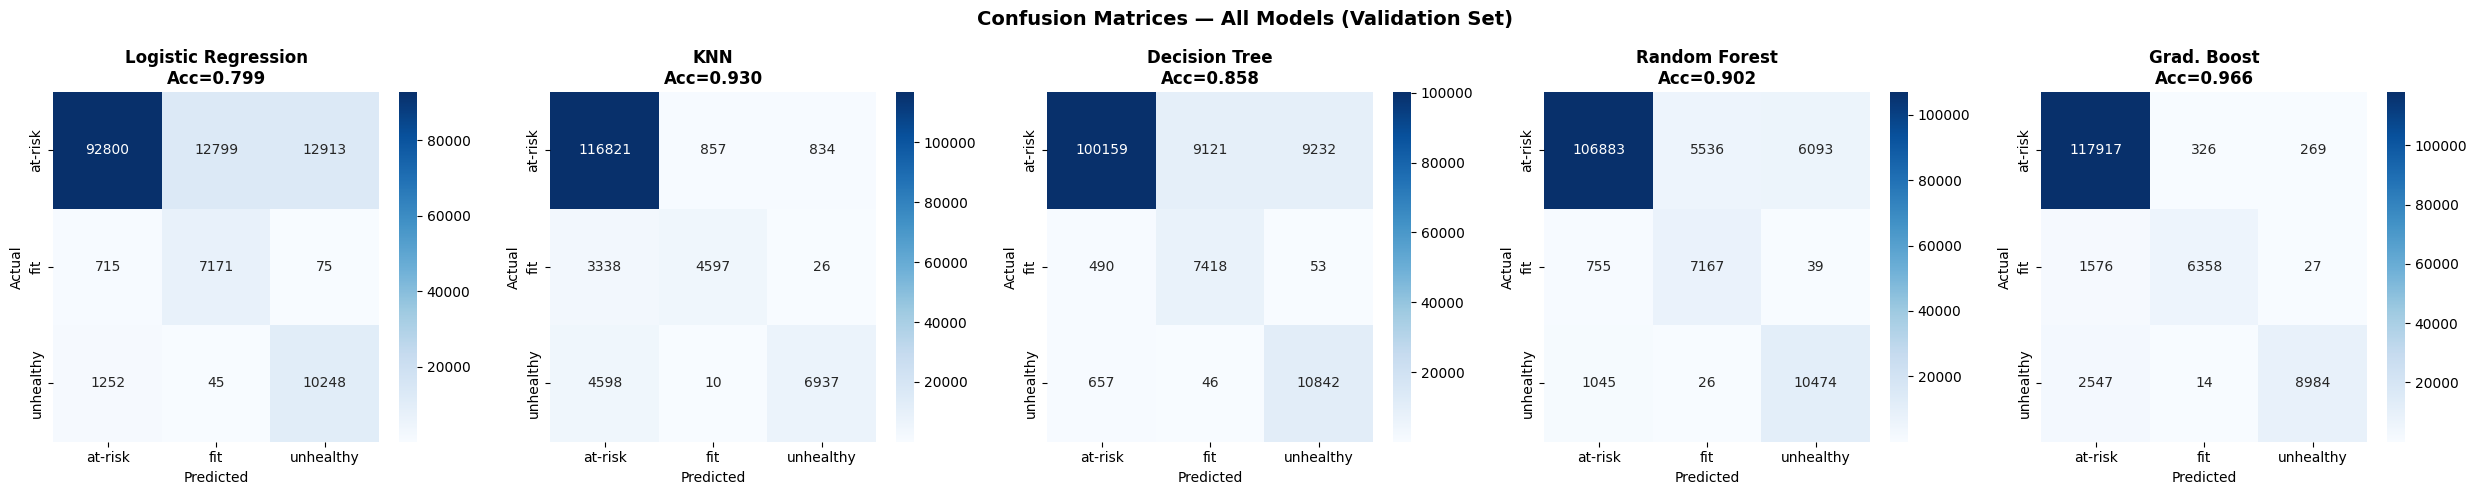


📊 INTERPRETATION:
   - Perfect model: only diagonal has values
   - Off-diagonal = wrong predictions
   - Darker diagonal = better model


In [4]:
# ============================================================
# SECTION 3: Confusion Matrices for All Models
# ============================================================

n_models = len(models)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5))
fig.suptitle('Confusion Matrices — All Models (Validation Set)', fontsize=14, fontweight='bold')

if n_models == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_val, res['y_val_pred'])
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        ax=ax
    )
    short_name = name.replace('Gradient Boosting', 'Grad. Boost').replace('K-Nearest Neighbours', 'KNN')
    ax.set_title(f'{short_name}\nAcc={res["val_acc"]:.3f}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'processed' / 'model_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 INTERPRETATION:')
print('   - Perfect model: only diagonal has values')
print('   - Off-diagonal = wrong predictions')
print('   - Darker diagonal = better model')

## 4. Full Classification Reports

**Why:** The classification report shows Precision, Recall, and F1-Score PER CLASS — essential for understanding per-class performance.

In [5]:
# ============================================================
# SECTION 4: Detailed Classification Reports
# ============================================================

for name, res in results.items():
    print('=' * 60)
    print(f'  {name}')
    print('=' * 60)
    print(classification_report(
        y_val,
        res['y_val_pred'],
        target_names=CLASS_NAMES
    ))
    print()

  Logistic Regression
              precision    recall  f1-score   support

     at-risk       0.98      0.78      0.87    118512
         fit       0.36      0.90      0.51      7961
   unhealthy       0.44      0.89      0.59     11545

    accuracy                           0.80    138018
   macro avg       0.59      0.86      0.66    138018
weighted avg       0.90      0.80      0.83    138018


  K-Nearest Neighbours
              precision    recall  f1-score   support

     at-risk       0.94      0.99      0.96    118512
         fit       0.84      0.58      0.68      7961
   unhealthy       0.89      0.60      0.72     11545

    accuracy                           0.93    138018
   macro avg       0.89      0.72      0.79    138018
weighted avg       0.93      0.93      0.92    138018


  Decision Tree
              precision    recall  f1-score   support

     at-risk       0.99      0.85      0.91    118512
         fit       0.45      0.93      0.60      7961
   unhealthy

## 5. Save All Trained Models

In [6]:
# ============================================================
# SECTION 5: Save All Models
# ============================================================

model_filename_map = {
    'Logistic Regression'   : 'model_logistic_regression.joblib',
    'K-Nearest Neighbours'  : 'model_knn.joblib',
    'Decision Tree'         : 'model_decision_tree.joblib',
    'Random Forest'         : 'model_random_forest.joblib',
    'Gradient Boosting'     : 'model_gradient_boosting.joblib'
}

for name, filename in model_filename_map.items():
    if name in results:
        joblib.dump(results[name]['model'], MODELS_DIR / filename)
        print(f'  ✅ Saved: models/{filename}')

# Save results summary
results_summary = pd.DataFrame([
    {
        'Model'        : name,
        'Train Acc'    : res['train_acc'],
        'Val Acc'      : res['val_acc'],
        'Val F1'       : res['val_f1'],
        'Train Time(s)': res['train_time']
    }
    for name, res in results.items()
]).sort_values('Val Acc', ascending=False)

results_summary.to_csv(PROC_DATA / 'model_results.csv', index=False)

print('\n=' * 60)
print('  MODEL PERFORMANCE LEADERBOARD')
print('=' * 60)
print(results_summary.to_string(index=False))
print('=' * 60)
print('  ✅ Ready for Phase 8: Model Evaluation')
print('=' * 60)

  ✅ Saved: models/model_logistic_regression.joblib
  ✅ Saved: models/model_knn.joblib
  ✅ Saved: models/model_decision_tree.joblib


  ✅ Saved: models/model_random_forest.joblib
  ✅ Saved: models/model_gradient_boosting.joblib

=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
  MODEL PERFORMANCE LEADERBOARD
               Model  Train Acc  Val Acc   Val F1  Train Time(s)
   Gradient Boosting   0.966149 0.965519 0.964037      54.057148
K-Nearest Neighbours   1.000000 0.929987 0.924193      12.989873
       Random Forest   0.912131 0.902230 0.910123     131.445405
       Decision Tree   0.859002 0.857997 0.874631      14.416939
 Logistic Regression   0.796894 0.798584 0.826097       3.640337
  ✅ Ready for Phase 8: Model Evaluation
